In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct



In [3]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 68.8M/68.8M [00:03<00:00, 18.1MB/s]

Extracting files...


Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset




# MNIST

## Downloaded 4 rows of ubyte files from koogle
###### Sourse : https://www.kaggle.com/datasets/hojjatk/mnist-dataset

In [4]:
train_images_m = '/content/drive/My Drive/Colab/BigData/ITCS-458-Project/mnist/train-images.idx3-ubyte'
train_labels_m = '/content/drive/My Drive/Colab/BigData/ITCS-458-Project/mnist/train-labels.idx1-ubyte'
test_images_m  = '/content/drive/My Drive/Colab/BigData/ITCS-458-Project/mnist/t10k-images.idx3-ubyte'
test_labels_m  = '/content/drive/My Drive/Colab/BigData/ITCS-458-Project/mnist/t10k-labels.idx1-ubyte'

In [5]:
# Read Train Images
with open(train_images_m, 'rb') as f:
    magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
    X_train_m = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
# Read Train Labels
with open(train_labels_m, 'rb') as f:
    magic, num = struct.unpack('>II', f.read(8))
    y_train_m = np.frombuffer(f.read(), dtype=np.uint8)
# Read Test Images
with open(test_images_m, 'rb') as f:
    magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
    X_test_m = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
# Read Test Labels
with open(test_labels_m, 'rb') as f:
    magic, num = struct.unpack('>II', f.read(8))
    y_test_m = np.frombuffer(f.read(), dtype=np.uint8)

In [6]:
# Total Number Samples
total_mnist_images_m = X_train_m.shape[0] + X_test_m.shape[0]
# Total Number Of Classes
num_mnist_classes_m = len(np.unique(y_train_m))

In [7]:
# Number of Samples
print(f" Number Of Samples: {total_mnist_images_m:,} ")
print(f" - {X_train_m.shape[0]:,} For Training")
print(f" - {X_test_m.shape[0]:,} For Testing")
# Number of Classes
print(f" Number Of Classes: {num_mnist_classes_m} Classes Presenting The Digits From {y_train_m.min()} To {y_train_m.max()}")
# Image Size
print(f" Image Size : {X_train_m.shape[1]} × {X_train_m.shape[2]} pixels")
# Image Type
print(f"Data Type: Grayscale Images Stored As Unsigned 8-BIT Integers, or {X_train_m.dtype}")

 Number Of Samples: 70,000 
 - 60,000 For Training
 - 10,000 For Testing
 Number Of Classes: 10 Classes Presenting The Digits From 0 To 9
 Image Size : 28 × 28 pixels
Data Type: Grayscale Images Stored As Unsigned 8-BIT Integers, or uint8


# FMNIST

### Downloaded Fashion-MNIST From koogle that contains 4 ubyte files and 2 .CSV
##### Sorce :  https://www.kaggle.com/datasets/zalando-research/fashionmnist

In [8]:
# Loading the train and test csv files
train = '/content/drive/MyDrive/Colab/BigData/ITCS-458-Project/fmnist/fashion-mnist_train.csv'
df_train = pd.read_csv(train)
test =  '/content/drive/MyDrive/Colab/BigData/ITCS-458-Project/fmnist/fashion-mnist_test.csv'
df_test = pd.read_csv(test)

In [9]:
# saparaiting labels from pixels
y_train_f = df_train.iloc[:,0].values
train_pixels = df_train.iloc[: , 1:].values

y_test_f = df_test.iloc[: , 0].values
test_pixels = df_test.iloc[: , 1:].values

In [10]:
# reshapping to 28 x 28 images
x_train_f = train_pixels.reshape(-1 , 28 , 28).astype(np.uint8)
x_test_f = test_pixels.reshape(-1 , 28 , 28 ).astype(np.uint8)

In [11]:
total_fmnist_images = x_train_f.shape[0] + x_test_f.shape[0]
num_fmnist_classes = len(np.unique(y_train_f))

In [12]:
# number of sample
print (f" Number Of Samples : {total_fmnist_images}")
print (f"  - {x_train_f.shape[0]}  For Training\n  - {x_test_f.shape[0]}  For Testing ")
# number of classes
print (f" Number Of Classes : {num_fmnist_classes} Presinting Clothes")
# image size
print (f" Image Seize : {x_train_f.shape[1]} x {x_train_f.shape[2]}")
# data type
print (f" Data Type: Grayscale Images Stored As Unsigned 8-BIT Integers, or {x_train_f.dtype}")

 Number Of Samples : 70000
  - 60000  For Training
  - 10000  For Testing 
 Number Of Classes : 10 Presinting Clothes
 Image Seize : 28 x 28
 Data Type: Grayscale Images Stored As Unsigned 8-BIT Integers, or uint8


In [13]:
# Part 2 : Data Exploration



# MNIST

In [14]:
# Simple list index = label number (0 to 9)

mnist_class_names = ['0','1','2','3','4','5','6','7','8','9']

print("MNIST Class Labels:")
for i, name in enumerate(mnist_class_names):
    print(f" Label {i} = Digit {name}")

MNIST Class Labels:
 Label 0 = Digit 0
 Label 1 = Digit 1
 Label 2 = Digit 2
 Label 3 = Digit 3
 Label 4 = Digit 4
 Label 5 = Digit 5
 Label 6 = Digit 6
 Label 7 = Digit 7
 Label 8 = Digit 8
 Label 9 = Digit 9


In [15]:
print("MNIST Dataset Shapes:")
print(f" Training images : {X_train_m.shape}")
print(f" Training labels : {y_train_m.shape}")
print(f" Testing images : {X_test_m.shape}")
print(f" Testing labels : {y_test_m.shape}")

MNIST Dataset Shapes:
 Training images : (60000, 28, 28)
 Training labels : (60000,)
 Testing images : (10000, 28, 28)
 Testing labels : (10000,)


In [16]:
# Check how many images are in each training set
# np.unique returns class and times it appeared

unique_classes_m, counts_m, = np.unique(y_train_m, return_counts=True)

print("MNIST Class Distribution (Training set):")
for cls, count in zip(unique_classes_m, counts_m):
    print(f" Digit {cls} : {count:,} images")

MNIST Class Distribution (Training set):
 Digit 0 : 5,923 images
 Digit 1 : 6,742 images
 Digit 2 : 5,958 images
 Digit 3 : 6,131 images
 Digit 4 : 5,842 images
 Digit 5 : 5,421 images
 Digit 6 : 5,918 images
 Digit 7 : 6,265 images
 Digit 8 : 5,851 images
 Digit 9 : 5,949 images


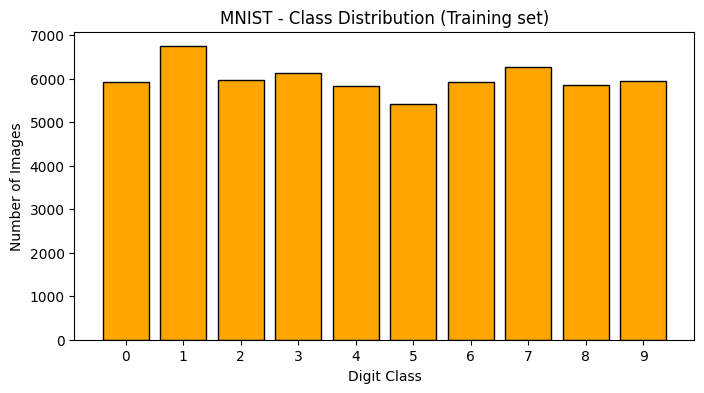

In [17]:
# Plot class distribution (Bar Chart)
plt.figure(figsize=(8,4))

plt.bar(unique_classes_m, counts_m, color='Orange', edgecolor='black')

plt.title("MNIST - Class Distribution (Training set)")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.xticks(unique_classes_m)
# Experimenting with formatting
# plt.tight_layout()
plt.show()

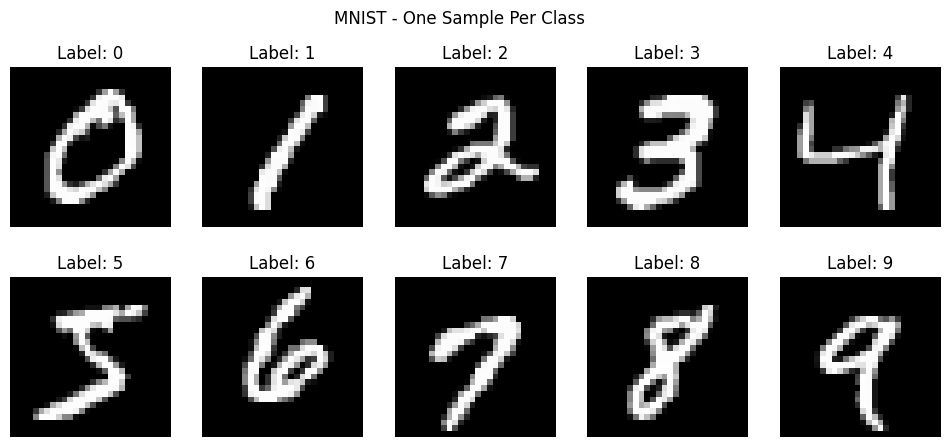

In [18]:
# Display one sample image, loop from 0 to 9
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("MNIST - One Sample Per Class",)

# axes.flatten() turns 2D grid into simple list
for i, ax in enumerate(axes.flatten()):

    index = np.where(y_train_m == i) [0][0]

    ax.imshow(X_train_m[index], cmap='gray')
    ax.set_title(f"Label: {i}")

    ax.axis('off')

plt.show()



# FMNIST

In [19]:
fmnist_class_names = [
    'T-shirt/Top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle Boot'    # 9
]

print("FMNIST Class Labels:")
for i, name in enumerate(fmnist_class_names):
    print(f" Label {i} = {name}")

FMNIST Class Labels:
 Label 0 = T-shirt/Top
 Label 1 = Trouser
 Label 2 = Pullover
 Label 3 = Dress
 Label 4 = Coat
 Label 5 = Sandal
 Label 6 = Shirt
 Label 7 = Sneaker
 Label 8 = Bag
 Label 9 = Ankle Boot


In [20]:
print("FMNIST Dataset Shapes:")
print(f" Training images : {x_train_f.shape}")
print(f" Training labels : {y_train_f.shape}")
print(f" Testing images : {x_test_f.shape}")
print(f" Testing labels : {y_test_f.shape}")

FMNIST Dataset Shapes:
 Training images : (60000, 28, 28)
 Training labels : (60000,)
 Testing images : (10000, 28, 28)
 Testing labels : (10000,)


In [21]:
unique_classes_f, counts_f, = np.unique(y_train_f, return_counts=True)

print("MNIST Class Distribution (Training set):")
for cls, count in zip(unique_classes_f, counts_f):
    print(f" {fmnist_class_names[cls]} (label{cls}) : {count:,} images")

MNIST Class Distribution (Training set):
 T-shirt/Top (label0) : 6,000 images
 Trouser (label1) : 6,000 images
 Pullover (label2) : 6,000 images
 Dress (label3) : 6,000 images
 Coat (label4) : 6,000 images
 Sandal (label5) : 6,000 images
 Shirt (label6) : 6,000 images
 Sneaker (label7) : 6,000 images
 Bag (label8) : 6,000 images
 Ankle Boot (label9) : 6,000 images


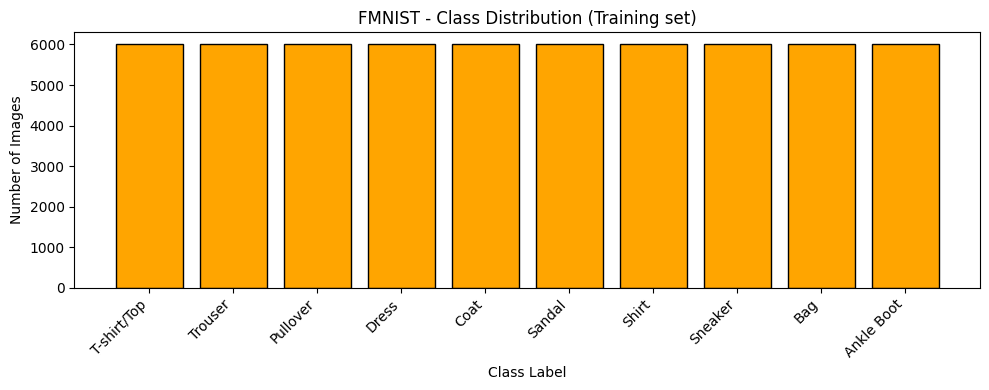

In [22]:
# Plot class distribution (Bar Chart)
plt.figure(figsize=(10,4))

plt.bar(unique_classes_f, counts_f, color='Orange', edgecolor='black')

plt.title("FMNIST - Class Distribution (Training set)")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")

plt.xticks(unique_classes_f, fmnist_class_names, rotation=45, ha='right')
# Experimenting with formatting
plt.tight_layout()
plt.show()

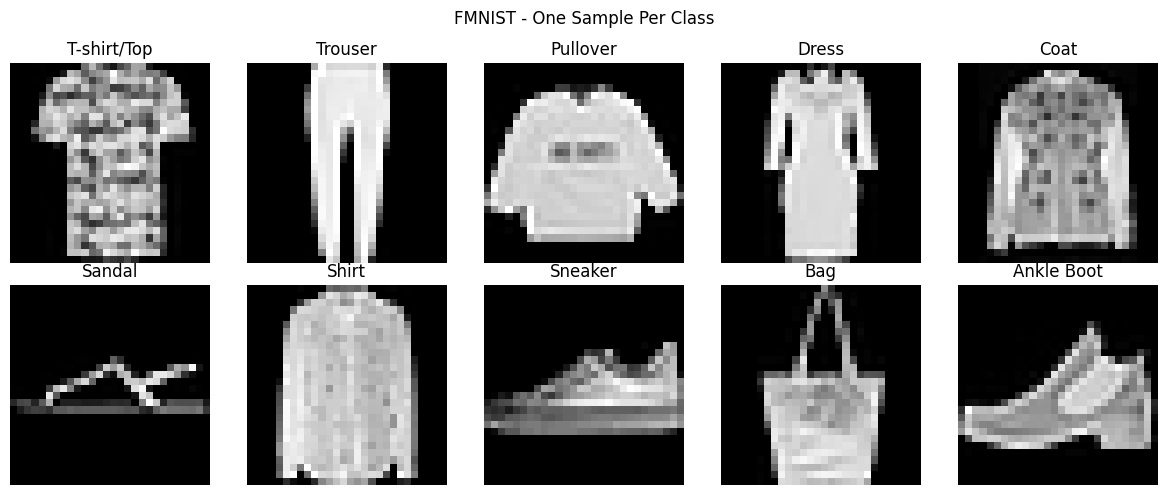

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("FMNIST - One Sample Per Class",)

for i, ax in enumerate(axes.flatten()):

    index = np.where(y_train_f == i) [0][0]

    ax.imshow(x_train_f[index], cmap='gray')
    ax.set_title(fmnist_class_names[i])

    ax.axis('off')
plt.tight_layout()
plt.show()

In [24]:
# part 3 : Data Preprocessing

#MNIST


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# Combine MNIST train and test data into one dataset
X_all_m = np.concatenate((X_train_m, X_test_m), axis=0)
y_all_m = np.concatenate((y_train_m, y_test_m), axis=0)

In [27]:
## 1. Normalization / Scaling
# Convert pixel values from 0-255 to 0-1
X_all_m = X_all_m.astype("float32") / 255.0

In [28]:
# 2. Reshaping images into vector form
# Each 28x28 image becomes 784 features
X_all_m = X_all_m.reshape(X_all_m.shape[0], 28 * 28)


In [29]:
# 3. Train-Test Split
X_train_m_pre, X_test_m_pre, y_train_m_pre, y_test_m_pre = train_test_split(
    X_all_m,
    y_all_m,
    test_size=0.2,
    random_state=42,
    stratify=y_all_m
)

In [30]:
# 4. Label Preparation
# Labels are already numeric (0–9), so no encoding is required

In [31]:

print("MNIST Preprocessing Completed")
print("Training images shape:", X_train_m_pre.shape)
print("Testing images shape:", X_test_m_pre.shape)
print("Training labels shape:", y_train_m_pre.shape)
print("Testing labels shape:", y_test_m_pre.shape)
print("Testing Normalization / Scaling:", X_train_m_pre.min(), X_train_m_pre.max())

MNIST Preprocessing Completed
Training images shape: (56000, 784)
Testing images shape: (14000, 784)
Training labels shape: (56000,)
Testing labels shape: (14000,)
Testing Normalization / Scaling: 0.0 1.0


#FMNIST

In [32]:
# Combine Fashion-MNIST train and test data into one dataset
X_all_f = np.concatenate((x_train_f, x_test_f), axis=0)
y_all_f = np.concatenate((y_train_f, y_test_f), axis=0)


In [33]:
# 1. Normalization / Scaling
# Convert pixel values from 0-255 to 0-1
X_all_f = X_all_f.astype("float32") / 255.0


In [34]:
# 2. Reshaping images into vector form
# Each 28x28 image becomes 784 features
X_all_f = X_all_f.reshape(X_all_f.shape[0], 28 * 28)

In [35]:
# 3. Train-test split
X_train_f_pre, X_test_f_pre, y_train_f_pre, y_test_f_pre = train_test_split(
    X_all_f,
    y_all_f,
    test_size=0.2,
    random_state=42,
    stratify=y_all_f
)

In [36]:
# 4. Label Preparation
# Labels are already numeric (0–9), so no encoding is required
y_train_f_pre = y_train_f
y_test_f_pre  = y_test_f

In [37]:
print("Fashion-MNIST Preprocessing Completed")
print("Training images shape:", X_train_f_pre.shape)
print("Testing images shape:", X_test_f_pre.shape)
print("Training labels shape:", y_train_f_pre.shape)
print("Testing labels shape:", y_test_f_pre.shape)

Fashion-MNIST Preprocessing Completed
Training images shape: (56000, 784)
Testing images shape: (14000, 784)
Training labels shape: (60000,)
Testing labels shape: (10000,)


In [38]:
# part 4 : Model Training

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#MNIST

In [40]:
print("Training on MNIST Dataset")

Training on MNIST Dataset


In [41]:
# Reshaping MNIST
X_train_m = X_train_m.reshape(X_train_m.shape[0], -1)
X_test_m = X_test_m.reshape(X_test_m.shape[0], -1)

In [42]:
# Reshaping FMNIST
X_train_f = x_train_f.reshape(x_train_f.shape[0], -1)
X_test_f = x_test_f.reshape(x_test_f.shape[0], -1)

In [43]:
#Training the dataset using Logistic Regression model
mnist_lr = LogisticRegression(max_iter=200)
mnist_lr.fit(X_train_m, y_train_m)
mnist_lr_pred = mnist_lr.predict(X_test_m)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
#Training the dataset using KNN model
mnist_knn = KNeighborsClassifier(n_neighbors=5)
mnist_knn.fit(X_train_m, y_train_m)
mnist_knn_pred = mnist_knn.predict(X_test_m)

In [45]:
#Training the dataset using Decision Tree model
mnist_dt = DecisionTreeClassifier()
mnist_dt.fit(X_train_m, y_train_m)
mnist_dt_pred = mnist_dt.predict(X_test_m)

In [46]:
print("Training on MNIST has been successful!")

Training on MNIST has been successful!


#FMNIST

In [47]:
print("Training on FMNIST Dataset")

Training on FMNIST Dataset


In [48]:
#Training the dataset using Logistic Regression model
fmnist_lr = LogisticRegression(max_iter=200)
fmnist_lr.fit(X_train_f, y_train_f)
fmnist_lr_pred = fmnist_lr.predict(X_test_f)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
#Training the dataset using KNN model
fmnist_knn = KNeighborsClassifier(n_neighbors=5)
fmnist_knn.fit(X_train_f, y_train_f)
fmnist_knn_pred = fmnist_knn.predict(X_test_f)

In [50]:
#Training the dataset using Decision Tree model
fmnist_dt = DecisionTreeClassifier()
fmnist_dt.fit(X_train_f, y_train_f)
fmnist_dt_pred = fmnist_dt.predict(X_test_f)

In [51]:
print("Training on FMNIST has been successful!")

Training on FMNIST has been successful!


In [52]:
print("Both datasets have been trained successfully!")

Both datasets have been trained successfully!


In [53]:
#Part5:

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [55]:
print("===== MNIST RESULTS =====")

# Accuracy
print("Logistic Regression Accuracy:",
      accuracy_score(y_test_m, mnist_lr_pred))

print("KNN Accuracy:",
      accuracy_score(y_test_m, mnist_knn_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test_m, mnist_dt_pred))

# Classification Reports
print("\n=== Logistic Regression Report ===")
print(classification_report(y_test_m, mnist_lr_pred))

print("\n=== KNN Report ===")
print(classification_report(y_test_m, mnist_knn_pred))

print("\n=== Decision Tree Report ===")
print(classification_report(y_test_m, mnist_dt_pred))


===== MNIST RESULTS =====
Logistic Regression Accuracy: 0.9228
KNN Accuracy: 0.9688
Decision Tree Accuracy: 0.8767

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.99      0.97      1135
           2       0.93      0.89      0.91      1032
           3       0.89      0.91      0.90      1010
           4       0.94      0.94      0.94       982
           5       0.89      0.85      0.87       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.87       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


=== KNN Report ===
              precision    recall  f1-score   support

           0   

In [56]:
print("\n===== FMNIST RESULTS =====")

# Accuracy
print("Logistic Regression Accuracy:",
      accuracy_score(y_test_f, fmnist_lr_pred))

print("KNN Accuracy:",
      accuracy_score(y_test_f, fmnist_knn_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test_f, fmnist_dt_pred))

# Classification Reports
print("\n=== Logistic Regression Report ===")
print(classification_report(y_test_f, fmnist_lr_pred))

print("\n=== KNN Report ===")
print(classification_report(y_test_f, fmnist_knn_pred))

print("\n=== Decision Tree Report ===")
print(classification_report(y_test_f, fmnist_dt_pred))


===== FMNIST RESULTS =====
Logistic Regression Accuracy: 0.8512
KNN Accuracy: 0.8589
Decision Tree Accuracy: 0.7978

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1000
           1       0.96      0.97      0.97      1000
           2       0.79      0.75      0.77      1000
           3       0.87      0.87      0.87      1000
           4       0.74      0.81      0.78      1000
           5       0.95      0.90      0.92      1000
           6       0.65      0.59      0.62      1000
           7       0.90      0.93      0.91      1000
           8       0.94      0.94      0.94      1000
           9       0.92      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


=== KNN Report ===
              precision    recall  f1-score   support

           0 

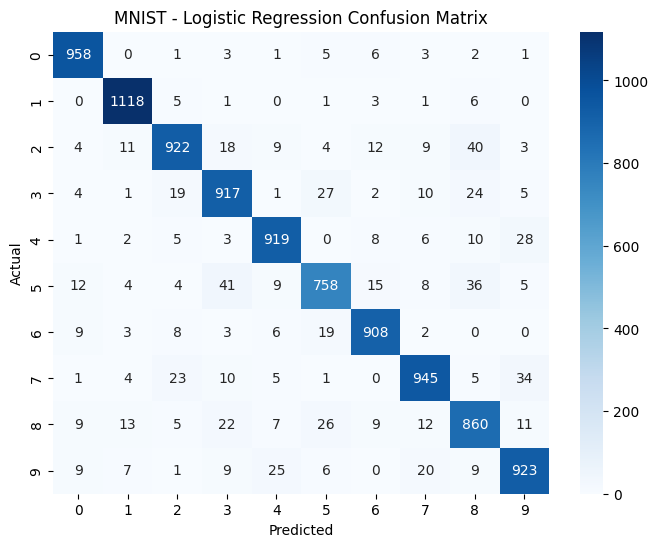

In [57]:
#confusion matrix:

cm = confusion_matrix(y_test_m, mnist_lr_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("MNIST - Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

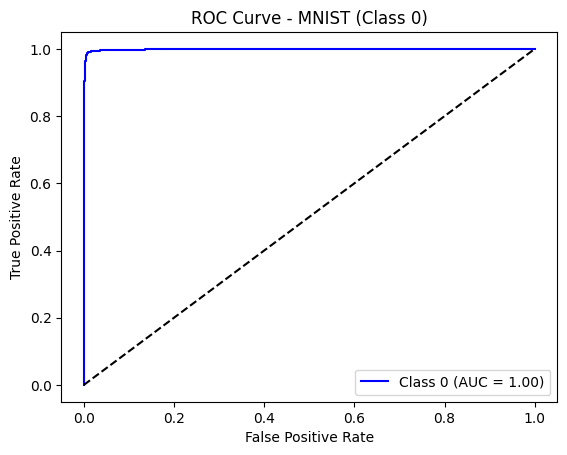

In [58]:
#extra ecvaluation ROC Curve for Mnist
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Example: MNIST Logistic Regression ROC

# Convert labels to binary format
y_test_bin = label_binarize(y_test_m, classes=[0,1,2,3,4,5,6,7,8,9])
n_classes = y_test_bin.shape[1]

# Get prediction probabilities
y_score = mnist_lr.predict_proba(X_test_m)

# Compute ROC curve and AUC for one class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot for one class (example class 0)
plt.figure()
plt.plot(fpr[0], tpr[0], color='blue',
         label=f'Class 0 (AUC = {roc_auc[0]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MNIST (Class 0)")
plt.legend()
plt.show()

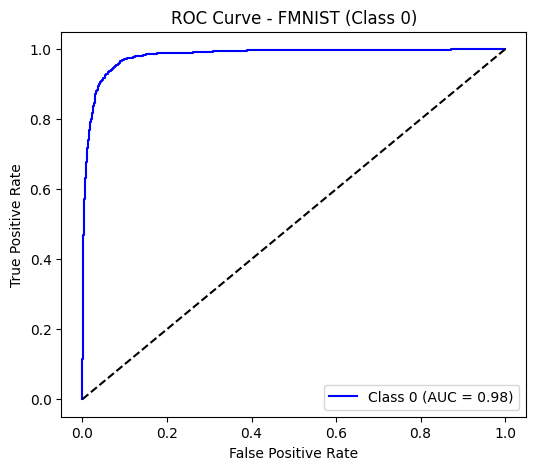

In [59]:
#extra ecvaluation ROC Curve for Fmnist
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert FMNIST labels into binary (one-vs-rest)
y_test_bin_f = label_binarize(y_test_f, classes=[0,1,2,3,4,5,6,7,8,9])
n_classes = y_test_bin_f.shape[1]

# Get probability predictions (Logistic Regression works best here)
y_score_f = fmnist_lr.predict_proba(X_test_f)

# Compute ROC curve for one class (example: class 0)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_f[:, i], y_score_f[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve (just class 0 for simplicity)
plt.figure(figsize=(6,5))
plt.plot(fpr[0], tpr[0], color='blue',
         label=f'Class 0 (AUC = {roc_auc[0]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FMNIST (Class 0)")
plt.legend()
plt.show()



In [60]:
#extra evaluation Error Rate Curve for Mnist

print("MNIST Logistic Regression Error Rate:",
      1 - accuracy_score(y_test_m, mnist_lr_pred))

MNIST Logistic Regression Error Rate: 0.07720000000000005


In [61]:
#extra evaluation Error Rate Curve for Fmnist

print("FMNIST Logistic Regression Error Rate:",
      1 - accuracy_score(y_test_f, fmnist_lr_pred))


FMNIST Logistic Regression Error Rate: 0.14880000000000004


In [62]:
#part6:

In [63]:
import matplotlib.pyplot as plt

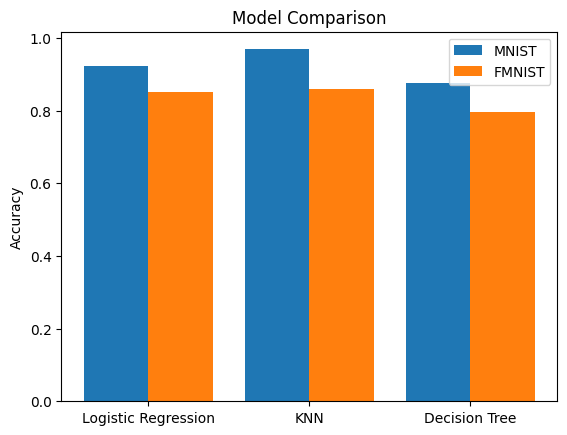

In [64]:
models = ['Logistic Regression', 'KNN', 'Decision Tree']
mnist_acc = [0.9228, 0.9688, 0.8762]
fmnist_acc = [0.8512, 0.8589, 0.7951]

import matplotlib.pyplot as plt

x = range(len(models))

plt.bar(x, mnist_acc, width=0.4, label='MNIST')
plt.bar([i + 0.4 for i in x], fmnist_acc, width=0.4, label='FMNIST')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.legend()
plt.show()


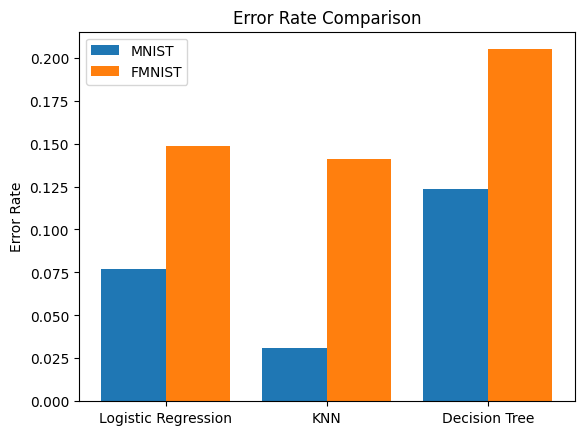

In [65]:
models = ['Logistic Regression', 'KNN', 'Decision Tree']

mnist_error = [0.0772, 0.0312, 0.1238]
fmnist_error = [0.1488, 0.1411, 0.2049]

x = range(len(models))

plt.bar(x, mnist_error, width=0.4, label='MNIST')
plt.bar([i + 0.4 for i in x], fmnist_error, width=0.4, label='FMNIST')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Error Rate")
plt.title("Error Rate Comparison")

plt.legend()
plt.show()

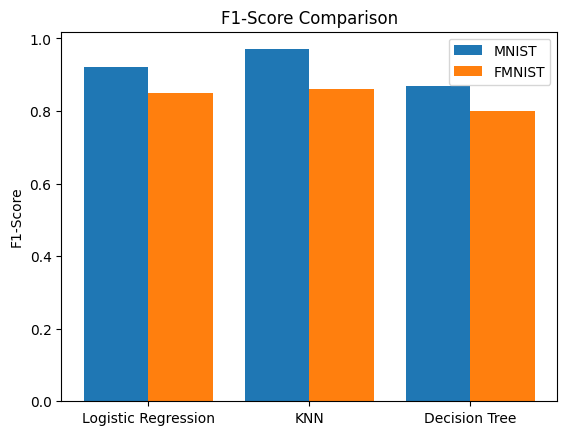

In [66]:
mnist_f1 = [0.92, 0.97, 0.87]
fmnist_f1 = [0.85, 0.86, 0.80]

x = range(len(models))

plt.bar(x, mnist_f1, width=0.4, label='MNIST')
plt.bar([i + 0.4 for i in x], fmnist_f1, width=0.4, label='FMNIST')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("F1-Score")
plt.title("F1-Score Comparison")

plt.legend()
plt.show()